# 04.2 — Hypothesis 2

## Negative emotion and working-memory impairment

### Hypothesis

Negative emotional induction leads to poorer working-memory performance
relative to the neutral emotional condition.

### Primary comparison

- Negative condition
- Neutral condition

### Primary outcomes

1. Trial-level response accuracy.
2. Reaction time among valid correct-response trials.

### Secondary analysis

The joint pattern of accuracy and reaction time is evaluated to determine
whether the negative condition produces a speed–accuracy trade-off.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from src import config as cfg

from src.utils import initialize_project

initialize_project()

## 3. Carregar os dados

In [2]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

print(f"Full dataset: {analysis.shape}")
print(f"Participants: {analysis['participant_id'].nunique()}")

Full dataset: (17820, 63)
Participants: 23


## 4. Selecionar Negative e Neutral

In [3]:
h2_data = (
    analysis.loc[
        analysis["emotion_condition"].isin(
            ["Neutral", "Negative"]
        )
    ]
    .copy()
)

print(f"H2 dataset: {h2_data.shape}")

print(
    h2_data["emotion_condition"]
    .value_counts()
)

H2 dataset: (11880, 63)
emotion_condition
Neutral     5940
Negative    5940
Name: count, dtype: int64


In [4]:
assert set(
    h2_data["emotion_condition"].dropna().unique()
) == {"Neutral", "Negative"}

## 5. Auditoria da amostra

In [5]:
h2_sample = (
    h2_data
    .groupby("emotion_condition")
    .agg(
        participants=("participant_id", "nunique"),
        trials=("accuracy", "size"),
        valid_accuracy=("accuracy", "count"),
    )
    .reset_index()
)

h2_sample

,emotion_condition,participants,trials,valid_accuracy
0,Negative,22,5940,5940
1,Neutral,23,5940,5940


In [6]:
participant_condition_counts = (
    h2_data[
        [
            "participant_id",
            "emotion_condition",
        ]
    ]
    .drop_duplicates()
    .groupby("participant_id")
    ["emotion_condition"]
    .nunique()
)

print(
    "Participants contributing to both conditions:",
    (participant_condition_counts == 2).sum(),
)

print(
    "Participants contributing to one condition:",
    (participant_condition_counts == 1).sum(),
)

Participants contributing to both conditions: 22
Participants contributing to one condition: 1


# Accuracy

## 6. Estatísticas descritivas

In [7]:
accuracy_summary_h2 = (
    h2_data
    .groupby("emotion_condition")
    .agg(
        participants=("participant_id", "nunique"),
        trials=("accuracy", "size"),
        correct=("accuracy", "sum"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_sd=("accuracy", "std"),
        accuracy_median=("accuracy", "median"),
    )
    .reset_index()
)

accuracy_summary_h2

,emotion_condition,participants,trials,correct,accuracy_mean,accuracy_sd,accuracy_median
0,Negative,22,5940,4978,0.838047,0.368439,1.0
1,Neutral,23,5940,5049,0.850000,0.357101,1.0


## 7. Accuracy por participante e condição

In [8]:
participant_accuracy_h2 = (
    h2_data
    .groupby(
        [
            "participant_id",
            "emotion_condition",
        ]
    )
    ["accuracy"]
    .mean()
    .reset_index()
)

participant_accuracy_h2.head()

,participant_id,emotion_condition,accuracy
0,1101,Negative,0.870370
1,1101,Neutral,0.870370
2,1106,Negative,0.822222
3,1106,Neutral,0.840741
4,1107,Negative,0.911111


## 8. Figura de accuracy

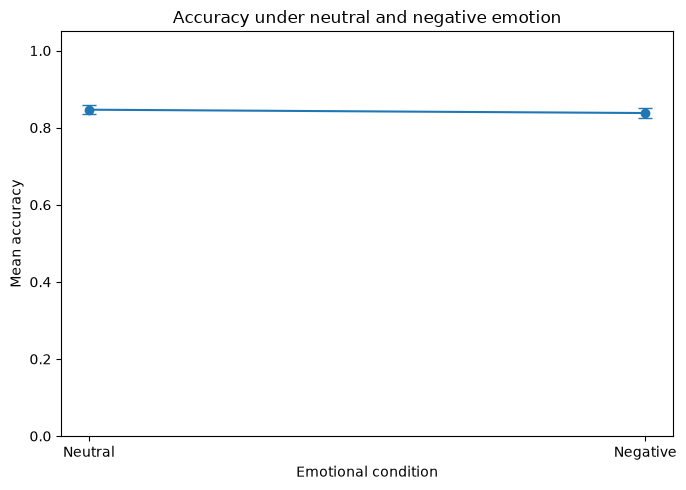

In [9]:
accuracy_plot_h2 = (
    participant_accuracy_h2
    .groupby("emotion_condition")
    ["accuracy"]
    .agg(["mean", "sem"])
    .reindex(["Neutral", "Negative"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    accuracy_plot_h2["emotion_condition"],
    accuracy_plot_h2["mean"],
    yerr=accuracy_plot_h2["sem"],
    marker="o",
    capsize=5,
)

ax.set_xlabel("Emotional condition")
ax.set_ylabel("Mean accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Accuracy under neutral and negative emotion")

fig.tight_layout()
plt.show()

## 9. GEE binomial

<br>

**Neutral as a reference**

In [10]:
accuracy_formula_h2 = (
    "accuracy ~ "
    "C(emotion_condition, Treatment(reference='Neutral'))"
)

accuracy_model_h2 = (
    smf.gee(
        formula=accuracy_formula_h2,
        groups="participant_id",
        data=h2_data,
        family=sm.families.Binomial(),
        cov_struct=sm.cov_struct.Exchangeable(),
    )
    .fit()
)

print(accuracy_model_h2.summary())

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                11880
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 135
                      Estimating Equations   Max. cluster size:                 540
Family:                           Binomial   Mean cluster size:               516.5
Dependence structure:         Exchangeable   Num. iterations:                     5
Date:                     Thu, 06 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         16:06:25
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------

## 10. Odds ratio

In [11]:
accuracy_ci_h2 = accuracy_model_h2.conf_int()

accuracy_results_h2 = pd.DataFrame(
    {
        "term": accuracy_model_h2.params.index,
        "beta": accuracy_model_h2.params.values,
        "se": accuracy_model_h2.bse.values,
        "z": accuracy_model_h2.tvalues.values,
        "p": accuracy_model_h2.pvalues.values,
        "ci_low": accuracy_ci_h2.iloc[:, 0].values,
        "ci_high": accuracy_ci_h2.iloc[:, 1].values,
    }
)

accuracy_results_h2["odds_ratio"] = np.exp(
    accuracy_results_h2["beta"]
)

accuracy_results_h2["or_ci_low"] = np.exp(
    accuracy_results_h2["ci_low"]
)

accuracy_results_h2["or_ci_high"] = np.exp(
    accuracy_results_h2["ci_high"]
)

accuracy_results_h2

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,Intercept,1.720318,0.081517,21.103847,7.332194e-99,1.560548,1.880088,5.586305,4.761430,6.554082
1,"C(emotion_condition, Treatment(reference='Neut...",-0.081021,0.064575,-1.254682,2.095942e-01,-0.207585,0.045543,0.922174,0.812544,1.046596


In [12]:
accuracy_contrast_h2 = (
    accuracy_results_h2.loc[
        accuracy_results_h2["term"]
        .str.contains("Negative", regex=False)
    ]
    .copy()
)

accuracy_contrast_h2

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
1,"C(emotion_condition, Treatment(reference='Neut...",-0.081021,0.064575,-1.254682,0.209594,-0.207585,0.045543,0.922174,0.812544,1.046596


# Reaction time

## 11. Base analítica de RT

In [13]:
rt_h2 = (
    h2_data.loc[
        (h2_data["accuracy"] == 1)
        & (h2_data["rt_valid"] == True)
    ]
    .copy()
)

rt_h2["log_rt"] = np.log(
    rt_h2["reaction_time_ms"]
)

print(f"RT observations: {len(rt_h2)}")
print(f"RT participants: {rt_h2['participant_id'].nunique()}")

RT observations: 9533
RT participants: 23


## 12. Estatísticas descritivas de RT

In [14]:
rt_summary_h2 = (
    rt_h2
    .groupby("emotion_condition")
    .agg(
        participants=("participant_id", "nunique"),
        trials=("reaction_time_ms", "size"),
        mean_rt=("reaction_time_ms", "mean"),
        sd_rt=("reaction_time_ms", "std"),
        median_rt=("reaction_time_ms", "median"),
        mean_log_rt=("log_rt", "mean"),
    )
    .reset_index()
)

rt_summary_h2

,emotion_condition,participants,trials,mean_rt,sd_rt,median_rt,mean_log_rt
0,Negative,22,4704,740.248724,744.225627,433.5,6.249127
1,Neutral,23,4829,966.584593,896.358283,630.0,6.511630


## 13. RT por participante e condição

In [15]:
participant_rt_h2 = (
    rt_h2
    .groupby(
        [
            "participant_id",
            "emotion_condition",
        ]
    )
    .agg(
        mean_rt=("reaction_time_ms", "mean"),
        median_rt=("reaction_time_ms", "median"),
        mean_log_rt=("log_rt", "mean"),
    )
    .reset_index()
)

participant_rt_h2.head()

,participant_id,emotion_condition,mean_rt,median_rt,mean_log_rt
0,1101,Negative,690.798246,461.0,6.237602
1,1101,Neutral,696.746725,437.0,6.216401
2,1106,Negative,559.733010,356.0,6.047027
3,1106,Neutral,627.085586,473.0,6.212370
4,1107,Negative,461.557447,330.0,5.980404


## 14. Figura de RT

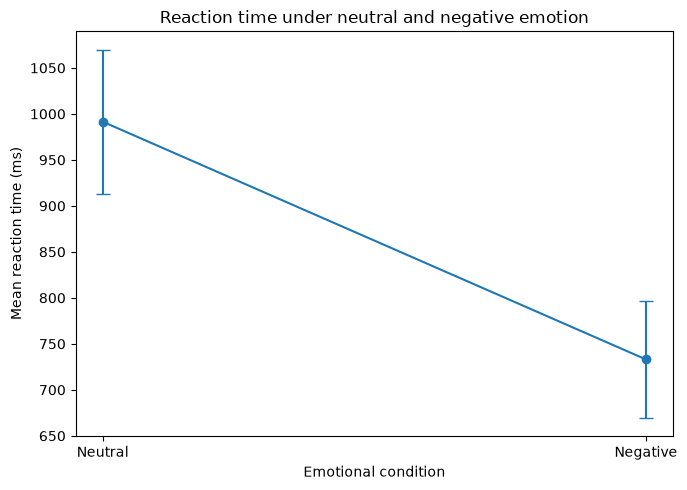

In [16]:
rt_plot_h2 = (
    participant_rt_h2
    .groupby("emotion_condition")
    ["mean_rt"]
    .agg(["mean", "sem"])
    .reindex(["Neutral", "Negative"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    rt_plot_h2["emotion_condition"],
    rt_plot_h2["mean"],
    yerr=rt_plot_h2["sem"],
    marker="o",
    capsize=5,
)

ax.set_xlabel("Emotional condition")
ax.set_ylabel("Mean reaction time (ms)")
ax.set_title("Reaction time under neutral and negative emotion")

fig.tight_layout()
plt.show()

## 15. Mixed-effects model

In [17]:
rt_formula_h2 = (
    "log_rt ~ "
    "C(emotion_condition, Treatment(reference='Neutral'))"
)

rt_model_h2 = smf.mixedlm(
    formula=rt_formula_h2,
    data=rt_h2,
    groups=rt_h2["participant_id"],
)

rt_result_h2 = rt_model_h2.fit(
    reml=False
)

print(rt_result_h2.summary())

                                   Mixed Linear Model Regression Results
Model:                             MixedLM                  Dependent Variable:                  log_rt     
No. Observations:                  9533                     Method:                              ML         
No. Groups:                        23                       Scale:                               0.5573     
Min. group size:                   108                      Log-Likelihood:                      -10791.6686
Max. group size:                   480                      Converged:                           Yes        
Mean group size:                   414.5                                                                    
------------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------

## 16. Converter o efeito para percentual

In [18]:
rt_ci_h2 = rt_result_h2.conf_int()

rt_results_h2 = pd.DataFrame(
    {
        "term": rt_result_h2.params.index,
        "beta": rt_result_h2.params.values,
        "se": rt_result_h2.bse.values,
        "z": rt_result_h2.tvalues.values,
        "p": rt_result_h2.pvalues.values,
        "ci_low": rt_ci_h2.iloc[:, 0].values,
        "ci_high": rt_ci_h2.iloc[:, 1].values,
    }
)

rt_results_h2["rt_ratio"] = np.exp(
    rt_results_h2["beta"]
)

rt_results_h2["percent_change"] = (
    np.exp(rt_results_h2["beta"]) - 1
) * 100

rt_results_h2["percent_ci_low"] = (
    np.exp(rt_results_h2["ci_low"]) - 1
) * 100

rt_results_h2["percent_ci_high"] = (
    np.exp(rt_results_h2["ci_high"]) - 1
) * 100

rt_contrast_h2 = (
    rt_results_h2.loc[
        rt_results_h2["term"]
        .str.contains("Negative", regex=False)
    ]
    .copy()
)

rt_contrast_h2

,term,beta,se,z,p,ci_low,ci_high,rt_ratio,percent_change,percent_ci_low,percent_ci_high
1,"C(emotion_condition, Treatment(reference='Neut...",-0.267821,0.015422,-17.366092,1.490370e-67,-0.298048,-0.237595,0.765044,-23.495566,-25.773446,-21.147782


# Speed–accuracy trade-off

## 17. Construir base participante × condição

In [19]:
participant_performance_h2 = (
    participant_accuracy_h2
    .merge(
        participant_rt_h2[
            [
                "participant_id",
                "emotion_condition",
                "mean_rt",
                "median_rt",
            ]
        ],
        on=[
            "participant_id",
            "emotion_condition",
        ],
        how="left",
        validate="one_to_one",
    )
)

participant_performance_h2["inverse_efficiency"] = (
    participant_performance_h2["mean_rt"]
    / participant_performance_h2["accuracy"]
)

participant_performance_h2.head()

,participant_id,emotion_condition,accuracy,mean_rt,median_rt,inverse_efficiency
0,1101,Negative,0.870370,690.798246,461.0,793.683091
1,1101,Neutral,0.870370,696.746725,437.0,800.517514
2,1106,Negative,0.822222,559.733010,356.0,680.756363
3,1106,Neutral,0.840741,627.085586,473.0,745.872723
4,1107,Negative,0.911111,461.557447,330.0,506.587442


## 18. Descrever eficiência

In [20]:
efficiency_summary_h2 = (
    participant_performance_h2
    .groupby("emotion_condition")
    .agg(
        n=("participant_id", "count"),
        mean_accuracy=("accuracy", "mean"),
        mean_rt=("mean_rt", "mean"),
        median_rt=("median_rt", "median"),
        mean_ies=("inverse_efficiency", "mean"),
        sd_ies=("inverse_efficiency", "std"),
    )
    .reset_index()
)

efficiency_summary_h2

,emotion_condition,n,mean_accuracy,mean_rt,median_rt,mean_ies,sd_ies
0,Negative,22,0.838047,733.013526,422.5,875.113822,342.301087
1,Neutral,23,0.846699,991.486311,531.0,1184.090140,481.792595


## 19. Comparação pareada exploratória do IES

<br>

O IES deve ser tratado como análise secundária, não como substituto dos modelos separados.

In [21]:
ies_wide_h2 = (
    participant_performance_h2
    .pivot_table(
        index="participant_id",
        columns="emotion_condition",
        values="inverse_efficiency",
        aggfunc="first",
    )
    .dropna(
        subset=["Neutral", "Negative"]
    )
)

ies_wide_h2.head()

emotion_condition,Negative,Neutral
participant_id,,
1101,793.683091,800.517514
1106,680.756363,745.872723
1107,506.587442,908.527373
1108,737.234429,679.644850
1122,1443.892049,1496.665793


In [22]:
from scipy import stats

ies_test_h2 = stats.ttest_rel(
    ies_wide_h2["Negative"],
    ies_wide_h2["Neutral"],
)

ies_test_h2

TtestResult(statistic=np.float64(-4.7350792870616365), pvalue=np.float64(0.00011229471428815889), df=np.int64(21))

In [23]:
ies_difference_h2 = (
    ies_wide_h2["Negative"]
    - ies_wide_h2["Neutral"]
)

ies_summary_test_h2 = pd.DataFrame(
    {
        "n": [len(ies_wide_h2)],
        "neutral_mean": [
            ies_wide_h2["Neutral"].mean()
        ],
        "negative_mean": [
            ies_wide_h2["Negative"].mean()
        ],
        "mean_difference": [
            ies_difference_h2.mean()
        ],
        "t": [ies_test_h2.statistic],
        "p": [ies_test_h2.pvalue],
    }
)

ies_summary_test_h2

,n,neutral_mean,negative_mean,mean_difference,t,p
0,22,1170.401766,875.113822,-295.287943,-4.735079,0.000112


# Interpretação automática

## 20. Classificar o padrão observado

In [24]:
negative_accuracy = (
    accuracy_summary_h2.loc[
        accuracy_summary_h2[
            "emotion_condition"
        ] == "Negative",
        "accuracy_mean",
    ].iloc[0]
)

neutral_accuracy = (
    accuracy_summary_h2.loc[
        accuracy_summary_h2[
            "emotion_condition"
        ] == "Neutral",
        "accuracy_mean",
    ].iloc[0]
)

negative_rt = (
    rt_summary_h2.loc[
        rt_summary_h2[
            "emotion_condition"
        ] == "Negative",
        "mean_rt",
    ].iloc[0]
)

neutral_rt = (
    rt_summary_h2.loc[
        rt_summary_h2[
            "emotion_condition"
        ] == "Neutral",
        "mean_rt",
    ].iloc[0]
)

In [25]:
accuracy_direction = (
    "lower"
    if negative_accuracy < neutral_accuracy
    else "higher"
)

rt_direction = (
    "slower"
    if negative_rt > neutral_rt
    else "faster"
)

print(
    f"Negative-condition accuracy was "
    f"{accuracy_direction} than neutral."
)

print(
    f"Negative-condition responses were "
    f"{rt_direction} than neutral."
)

Negative-condition accuracy was lower than neutral.
Negative-condition responses were faster than neutral.


## Decision rules

Hypothesis 2 is supported if negative emotion is associated with:

- significantly lower accuracy;
- significantly slower reaction time;
- or both lower accuracy and slower reaction time.

Hypothesis 2 is partially supported if:

- only one impairment outcome is statistically supported;
- or a speed–accuracy trade-off is observed, with faster but less
  accurate responses under negative emotion.

Hypothesis 2 is not supported if:

- negative emotion does not significantly reduce accuracy;
- and responses are not significantly slower than under neutral emotion.

## 22. Decisão programática inicial

In [26]:
accuracy_p_h2 = (
    accuracy_contrast_h2["p"].iloc[0]
)

accuracy_beta_h2 = (
    accuracy_contrast_h2["beta"].iloc[0]
)

rt_p_h2 = (
    rt_contrast_h2["p"].iloc[0]
)

rt_beta_h2 = (
    rt_contrast_h2["beta"].iloc[0]
)

accuracy_impairment = (
    accuracy_p_h2 < cfg.ALPHA
    and accuracy_beta_h2 < 0
)

rt_impairment = (
    rt_p_h2 < cfg.ALPHA
    and rt_beta_h2 > 0
)

faster_negative_rt = (
    rt_p_h2 < cfg.ALPHA
    and rt_beta_h2 < 0
)

if accuracy_impairment and rt_impairment:
    h2_assessment = "supported"

elif accuracy_impairment or rt_impairment:
    h2_assessment = "partially supported"

elif faster_negative_rt:
    h2_assessment = "not supported"

else:
    h2_assessment = "not supported"

print(
    "Hypothesis 2 assessment:",
    h2_assessment,
)

Hypothesis 2 assessment: not supported


# Exportar os resultados

## 23. Criar diretório H2

In [27]:
h2_output_dir = (
    cfg.TABLES_DIR
    / "hypothesis_02"
)

h2_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"H2 report tables directory: {h2_output_dir}")


# 24. Salvar tabelas

In [28]:
# Accuracy descriptive table
accuracy_summary_h2.to_csv(
    h2_output_dir
    / "h2_accuracy_descriptive.csv",
    index=False,
)

# Accuracy model: Negative vs Neutral contrast
accuracy_contrast_h2.to_csv(
    h2_output_dir
    / "h2_accuracy_model.csv",
    index=False,
)

# Reaction-time descriptive table
rt_summary_h2.to_csv(
    h2_output_dir
    / "h2_rt_descriptive.csv",
    index=False,
)

# Reaction-time model: Negative vs Neutral contrast
rt_contrast_h2.to_csv(
    h2_output_dir
    / "h2_rt_model.csv",
    index=False,
)

# Processing-efficiency descriptive table
efficiency_summary_h2.to_csv(
    h2_output_dir
    / "h2_efficiency_descriptive.csv",
    index=False,
)

# Processing-efficiency paired test
ies_summary_test_h2.to_csv(
    h2_output_dir
    / "h2_efficiency_test.csv",
    index=False,
)

print("H2 result tables saved successfully.")


## 25. Salvar um resumo da hipótese

In [29]:
h2_summary = pd.DataFrame(
    {
        "hypothesis": ["H2"],
        "comparison": [
            "Negative vs Neutral"
        ],
        "participants": [
            h2_data["participant_id"].nunique()
        ],
        "accuracy_observations": [
            len(h2_data)
        ],
        "rt_observations": [
            len(rt_h2)
        ],
        "accuracy_beta": [
            accuracy_beta_h2
        ],
        "accuracy_or": [
            accuracy_contrast_h2[
                "odds_ratio"
            ].iloc[0]
        ],
        "accuracy_p": [
            accuracy_p_h2
        ],
        "rt_beta_log": [
            rt_beta_h2
        ],
        "rt_percent_change": [
            rt_contrast_h2[
                "percent_change"
            ].iloc[0]
        ],
        "rt_p": [
            rt_p_h2
        ],
        "assessment": [
            h2_assessment
        ],
    }
)

h2_summary.to_csv(
    h2_output_dir
    / "h2_summary.csv",
    index=False,
)

h2_summary


,hypothesis,comparison,accuracy_beta,accuracy_p,rt_beta_log,rt_percent_change,rt_p,assessment
0,H2,Negative vs Neutral,-0.081021,0.209594,-0.267821,-23.495566,1.490370e-67,not supported


## Report export validation

Validate that all Hypothesis 2 report files exist and conform to the common reporting contract.


In [ ]:
expected_h2_files = {
    "accuracy_descriptive": h2_output_dir / "h2_accuracy_descriptive.csv",
    "accuracy_model": h2_output_dir / "h2_accuracy_model.csv",
    "rt_descriptive": h2_output_dir / "h2_rt_descriptive.csv",
    "rt_model": h2_output_dir / "h2_rt_model.csv",
    "efficiency_descriptive": h2_output_dir / "h2_efficiency_descriptive.csv",
    "efficiency_test": h2_output_dir / "h2_efficiency_test.csv",
    "summary": h2_output_dir / "h2_summary.csv",
}

expected_h2_schemas = {
    "accuracy_descriptive": [
        "emotion_condition", "participants", "trials", "correct",
        "accuracy_mean", "accuracy_sd", "accuracy_median",
    ],
    "accuracy_model": [
        "term", "beta", "se", "z", "p", "ci_low", "ci_high",
        "odds_ratio", "or_ci_low", "or_ci_high",
    ],
    "rt_descriptive": [
        "emotion_condition", "participants", "trials", "mean_rt",
        "sd_rt", "median_rt", "mean_log_rt",
    ],
    "rt_model": [
        "term", "beta", "se", "z", "p", "ci_low", "ci_high",
        "rt_ratio", "percent_change", "percent_ci_low", "percent_ci_high",
    ],
    "efficiency_descriptive": [
        "emotion_condition", "n", "mean_accuracy", "mean_rt",
        "median_rt", "mean_ies", "sd_ies",
    ],
    "efficiency_test": [
        "n", "neutral_mean", "negative_mean", "mean_difference", "t", "p",
    ],
    "summary": [
        "hypothesis", "comparison", "participants", "accuracy_observations",
        "rt_observations", "accuracy_beta", "accuracy_or", "accuracy_p",
        "rt_beta_log", "rt_percent_change", "rt_p", "assessment",
    ],
}

print("=" * 72)
print("H2 REPORT EXPORT VALIDATION")
print("=" * 72)

all_valid = True

for name, path in expected_h2_files.items():
    if not path.exists():
        print(f"{name:<24} MISSING  {path.name}")
        all_valid = False
        continue

    df_check = pd.read_csv(path)
    actual_columns = df_check.columns.tolist()
    expected_columns = expected_h2_schemas[name]
    schema_ok = actual_columns == expected_columns

    status = "OK" if schema_ok else "SCHEMA ERROR"
    print(f"{name:<24} {status:<12} {path.name}")

    if not schema_ok:
        all_valid = False
        print(f"  Expected: {expected_columns}")
        print(f"  Actual:   {actual_columns}")

print("-" * 72)
print(
    "All H2 report exports are valid."
    if all_valid
    else "One or more H2 exports require correction."
)


## Resumo geral

In [30]:
print("=" * 70)
print("HYPOTHESIS 2 ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"Participants: "
    f"{h2_data['participant_id'].nunique()}"
)

print(
    f"Accuracy observations: "
    f"{len(h2_data)}"
)

print(
    f"RT observations: "
    f"{len(rt_h2)}"
)

print(
    f"Negative accuracy: "
    f"{negative_accuracy:.3f}"
)

print(
    f"Neutral accuracy: "
    f"{neutral_accuracy:.3f}"
)

print(
    f"Accuracy OR: "
    f"{accuracy_contrast_h2['odds_ratio'].iloc[0]:.3f}"
)

print(
    f"Accuracy p: "
    f"{accuracy_p_h2:.4f}"
)

print(
    f"RT percent change: "
    f"{rt_contrast_h2['percent_change'].iloc[0]:.1f}%"
)

print(
    f"RT p: "
    f"{rt_p_h2:.4f}"
)

print(
    f"H2 assessment: "
    f"{h2_assessment}"
)

print("=" * 70)

HYPOTHESIS 2 ANALYSIS SUMMARY
Participants: 23
Accuracy observations: 11880
RT observations: 9533
Negative accuracy: 0.838
Neutral accuracy: 0.850
Accuracy OR: 0.922
Accuracy p: 0.2096
RT percent change: -23.5%
RT p: 0.0000
H2 assessment: not supported
